# 📓 **Notebook 2 — Phase 3**

**Project:** [Medical Transcription Classifier and Semantic Search Engine](https://github.com/bahadirkoko/medical-transcription-classifier)

## Phase 3 — Supervised Classification

This notebook trains and evaluates three machine learning classifiers on the
cleaned medical transcription dataset. Each note is vectorized into a TF-IDF
feature matrix and classified into one of ~26 medical specialties.

**Three models — three tradeoffs:**
- **Logistic Regression** — fast, interpretable (readable coefficients), strong baseline.
- **Multinomial Naive Bayes** — probabilistic, fastest, robust in high dimensions.
- **Random Forest** — non-linear, captures feature interactions, slowest.

**Key distinction from Phase 4:** these are *parametric* models — they learn
parameters (weights, probabilities, decision trees) from training data and can
predict without the original data afterward. Phase 4's semantic search is
non-parametric (stores the data, learns nothing).

### 🗂️ **Project notebooks**
1. Notebook 1 — Phases 1 & 2: Collection & Cleaning, Preprocessing for NLP, TF-IDF, Chi 2
2. **Notebook 2** — Phase 3: Model Trainings and Evaluation  **(you are here)**
3. Notebook 3 — Phases 4 & 5: Semantic Search Engine, Retrieval Validation 

## Imports & Data Load

In [1]:
# data
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt

# ML -- splitting, vectorization, models, metrics
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# load the processed dataset from Phase 1
df = pd.read_csv('../data/processed/cleaned_medical_notes.csv')
print("shape:", df.shape)
print("columns:", df.columns.tolist())

shape: (2586, 9)
columns: ['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords', 'char_length', 'word_count', 'sentence_count', 'clean_text']


## 3.1 — Data Preparation

### Specialty Filtering

We apply the same filtering as Phase 1: remove document-format categories
(not genuine medical specialties), Surgery (95% cross-listed), and Radiology
(95% cross-listed — service label whose notes are already preserved under
real clinical specialties).

Full justification with overlap evidence is in Notebook 1.

In [2]:
# remove document-format categories and structurally-redundant specialty labels
not_specialties = [
    'SOAP / Chart / Progress Notes', 'Office Notes', 'Letters',
    'Discharge Summary', 'Emergency Room Reports',
    'Consult - History and Phy.', 'IME-QME-Work Comp etc.',
    'Surgery',    # 95% cross-listed -- procedural label, not a distinct specialty
    'Radiology'   # 95% cross-listed -- service label, notes preserved under real specialties
]

df = df[~df['medical_specialty'].isin(not_specialties)].reset_index(drop=True)
print("rows:", len(df), "| classes:", df['medical_specialty'].nunique())
print(df['medical_specialty'].value_counts())

rows: 2586 | classes: 26
medical_specialty
Cardiovascular / Pulmonary    368
Orthopedic                    346
General Medicine              257
Neurology                     223
Gastroenterology              220
Obstetrics / Gynecology       155
Urology                       154
ENT - Otolaryngology           96
Neurosurgery                   94
Hematology - Oncology          90
Ophthalmology                  83
Nephrology                     81
Pediatrics - Neonatal          70
Pain Management                56
Psychiatry / Psychology        53
Podiatry                       47
Dermatology                    29
Dentistry                      27
Cosmetic / Plastic Surgery     27
Physical Medicine - Rehab      21
Sleep Medicine                 20
Endocrinology                  19
Bariatrics                     18
Chiropractic                   12
Rheumatology                   10
Diets and Nutritions           10
Name: count, dtype: int64


### Define Features (X) and Labels (y)

- **X** = what the model reads (cleaned note text, later vectorized into numbers).
- **y** = what the model must predict (the specialty label).

We use `clean_text` (not raw `transcription`) — Phase 1 cleaning reduces noise
and makes the TF-IDF vocabulary more informative.

In [3]:
X = df['clean_text']          # features: the text each model learns from
y = df['medical_specialty']   # labels: the correct specialty for each note

print("total notes:", len(X))
print("unique specialties:", y.nunique())

total notes: 2586
unique specialties: 26


### Train / Test Split

We hold out 20% of the data as a "final exam." The model **never sees test data
during training** — evaluating on unseen data is what makes the score honest.

`stratify=y` ensures every specialty is proportionally represented in both sets.
Without stratification, rare specialties might land entirely on one side of the
split, making training or evaluation on them impossible.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% held out -- model never sees this during training
    stratify=y,          # keep class proportions equal in both sets
    random_state=42      # fixed seed -- same split every run (reproducibility)
)

print("train:", len(X_train), "| test:", len(X_test))
# if stratify succeeded without error, every class has >= 2 examples -- good sign

train: 2068 | test: 518


### TF-IDF Vectorization

ML models need numbers, not text. TF-IDF converts each note into a row of scores
(one per vocabulary word) where high scores mark words that are frequent *in this
note* but rare *globally*. Common words ("patient") score near zero automatically;
distinctive words ("lithotripsy") score high.

**Critical rule — fit on train only, transform on test.**
If we fit the vectorizer on the test set too, it would learn test vocabulary and
peek at test data. The vocabulary and IDF weights must come from training data alone.

In [5]:
# de-identification artifacts and placeholder tokens to remove
# identified via Phase 2 chi-square: appeared as top features but carry no medical meaning
custom_noise = ['x', 'xx', 'xxx', 'dr', 'md', 'mrs', 'dear',
                'abc', 'xyz', 'mmddyyyy', 'yyyy', 'dd', 'yearold']

tfidf = TfidfVectorizer(
    max_features=10000,        # keep the 10,000 most informative n-grams
    ngram_range=(1, 3),        # unigrams + bigrams + trigrams
                               # trigrams capture medical phrases ("left ventricular ejection")
    stop_words=custom_noise,   # remove artifact tokens
    sublinear_tf=True          # log-scale TF: log(1 + tf) instead of raw tf
                               # prevents words appearing 50x dominating over words appearing 5x
)

# FIT on train: learn vocabulary + compute IDF weights from training notes ONLY
X_train_tfidf = tfidf.fit_transform(X_train)

# TRANSFORM test: apply the same learned vocab + IDF weights to test notes
# test data must NOT influence the vocabulary -- that would be data leakage
X_test_tfidf = tfidf.transform(X_test)

print("train matrix:", X_train_tfidf.shape)   # (train_notes x 10000 features)
print("test matrix: ", X_test_tfidf.shape)    # (test_notes  x 10000 features)
# both have the same number of columns -- same vocabulary, by design

train matrix: (2068, 10000)
test matrix:  (518, 10000)


---
## Phase 3.2 — Model Training: The Three-Tier Approach

Three models, each with a different mechanism and tradeoff. All use the same
train matrix and are evaluated on the same test matrix — so any performance
difference comes purely from the model, not the data.

Every sklearn classifier follows the same two-step interface:
- `.fit(X_train, y_train)` — learn from labeled training data.
- `.predict(X_test)` — classify new, unseen examples.

### Model 1 — Logistic Regression (The Interpretable Baseline)

Learns a **weight (coefficient) for every word, per specialty**. To classify a
note, it sums the weighted word scores and picks the highest-scoring specialty.
Linear, fast, and crucially — *interpretable*: you can read the coefficients.

`class_weight='balanced'` adjusts learning so rare specialties count more,
preventing the model from ignoring them to chase easy wins on common ones.

In [6]:
logreg = LogisticRegression(
    class_weight='balanced',   # up-weight rare specialties so they are not ignored
    max_iter=1000,             # default 100 often fails to converge on text data
    random_state=42
)

# .fit() = the learning step: adjusts coefficients to minimize prediction error
logreg.fit(X_train_tfidf, y_train)

# .predict() = classify each test note using the learned coefficients
logreg_preds = logreg.predict(X_test_tfidf)
print("Logistic Regression trained")

Logistic Regression trained


### Model 2 — Multinomial Naive Bayes (The Text Specialist)

Asks "given these words, which specialty is most *probable*?" using Bayes'
theorem. "Naive" = assumes every word contributes independently (technically
false, but works well for text). "Multinomial" = designed for word count/frequency
features, exactly what TF-IDF produces.

Fastest model, but has no `class_weight` parameter — it cannot be balanced,
so it may underperform on rare specialties.

In [7]:
nb = MultinomialNB()
# note: MultinomialNB has no class_weight parameter
# it treats all classes equally, which disadvantages rare specialties
# included as the classic probabilistic text-classification baseline

nb.fit(X_train_tfidf, y_train)
nb_preds = nb.predict(X_test_tfidf)
print("Naive Bayes trained")

Naive Bayes trained


### Model 3 — Random Forest (The Non-Linear Option)

Builds hundreds of decision trees on random data/feature subsets, then votes.
Captures non-linear patterns that linear models miss.

**Expectation:** often *underperforms* Logistic Regression on sparse TF-IDF data.
Tree splits struggle when most feature values are zero (most words absent from
most notes). We include it to demonstrate this common NLP counterintuitive result:
complexity does not always beat simplicity on text.

In [8]:
rf = RandomForestClassifier(
    n_estimators=200,          # build 200 decision trees and have them vote
    class_weight='balanced',   # up-weight rare specialties
    n_jobs=-1,                 # use all available CPU cores (forests are slow)
    random_state=42            # reproducible tree construction
)

rf.fit(X_train_tfidf, y_train)
rf_preds = rf.predict(X_test_tfidf)
print("Random Forest trained")

Random Forest trained


---
## Phase 3.3 — Evaluation & Model Comparison

### Metric 1 — Macro F1 (The Honest Metric)

**Why not just accuracy?** On imbalanced data, accuracy lies. A model that always
predicts the most common specialty could score high accuracy while ignoring all
rare classes. **Macro F1** treats every specialty equally: it averages F1 across
all classes so a rare specialty counts the same as a common one.

**The diagnostic — compare Accuracy vs. Macro F1:**
- **Small gap** → consistent performance across all specialties.
- **Large gap** → strong on common classes, failing on rare ones.

Three F1 variants:
- **Macro F1** — equal class weight (honest for imbalance).
- **Weighted F1** — weighted by class size (rewards common classes).
- **Accuracy** — fraction of all predictions that were correct.

In [9]:
for name, preds in [('Logistic Regression', logreg_preds),
                    ('Naive Bayes',         nb_preds),
                    ('Random Forest',       rf_preds)]:
    print(f"\n===== {name} =====")

    # accuracy: fraction of all predictions that were correct
    print("Accuracy:    ", round(accuracy_score(y_test, preds), 3))

    # macro F1: average F1 across ALL classes, equal weight per class
    # much lower than accuracy = model is ignoring rare specialties
    print("Macro F1:    ", round(f1_score(y_test, preds, average='macro'), 3))

    # weighted F1: average F1 weighted by class size
    # sits between macro F1 and accuracy -- rewards doing well on common classes
    print("Weighted F1: ", round(f1_score(y_test, preds, average='weighted'), 3))


===== Logistic Regression =====
Accuracy:     0.701
Macro F1:     0.657
Weighted F1:  0.703

===== Naive Bayes =====
Accuracy:     0.527
Macro F1:     0.227
Weighted F1:  0.471

===== Random Forest =====
Accuracy:     0.614
Macro F1:     0.563
Weighted F1:  0.612


**Reading the results:** the Accuracy-Macro F1 gap tells the main story. A large
gap means the model is strong on common specialties but failing the rare ones.
A small gap means consistent performance across all classes.

### Metric 2 — Confusion Matrix (Where the Leaks Are)

Each normalized matrix row sums to 1.0: "of all true Neurology notes, what
fraction were predicted as each specialty?" The diagonal = correct predictions.
Off-diagonal hotspots = systematic confusions.

**What to look for:** confusions that appear in all three models are
*inherent to the data* (those specialties genuinely share clinical vocabulary).
Confusions unique to one model are that model's specific weakness.

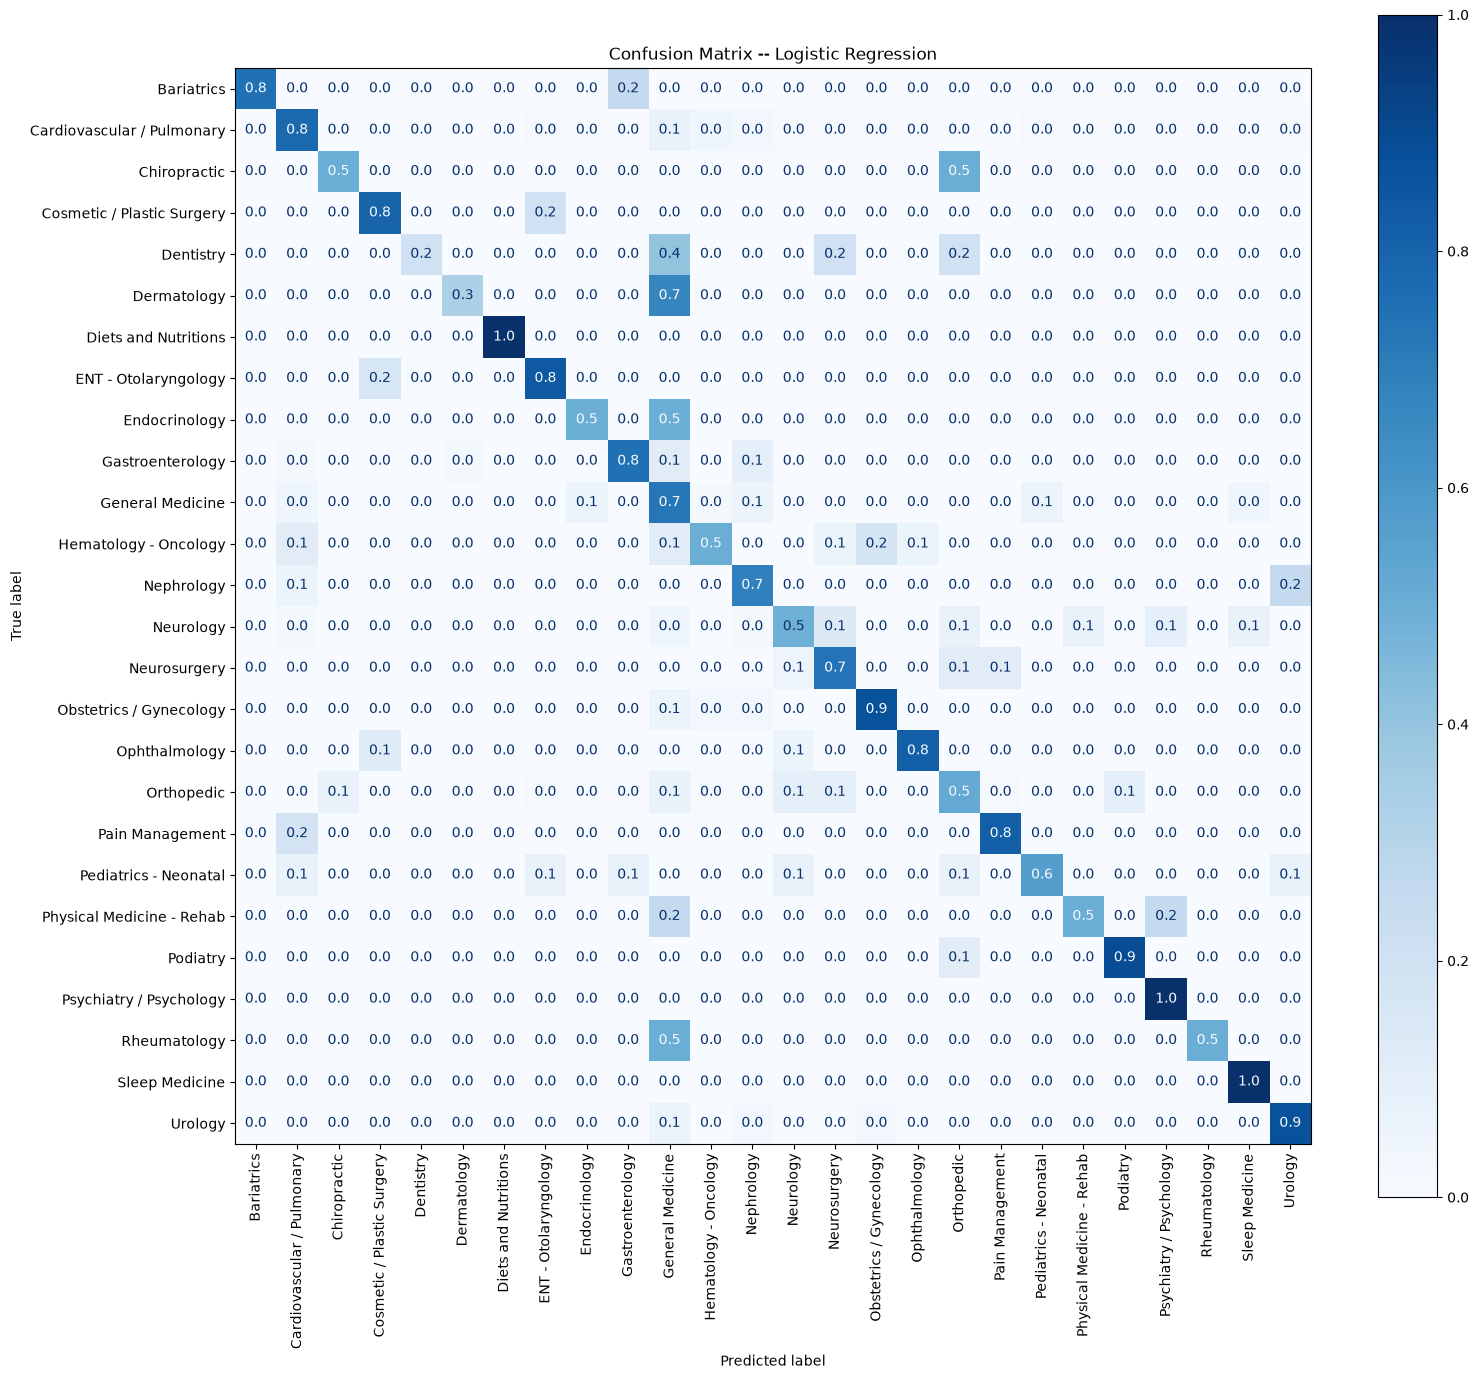

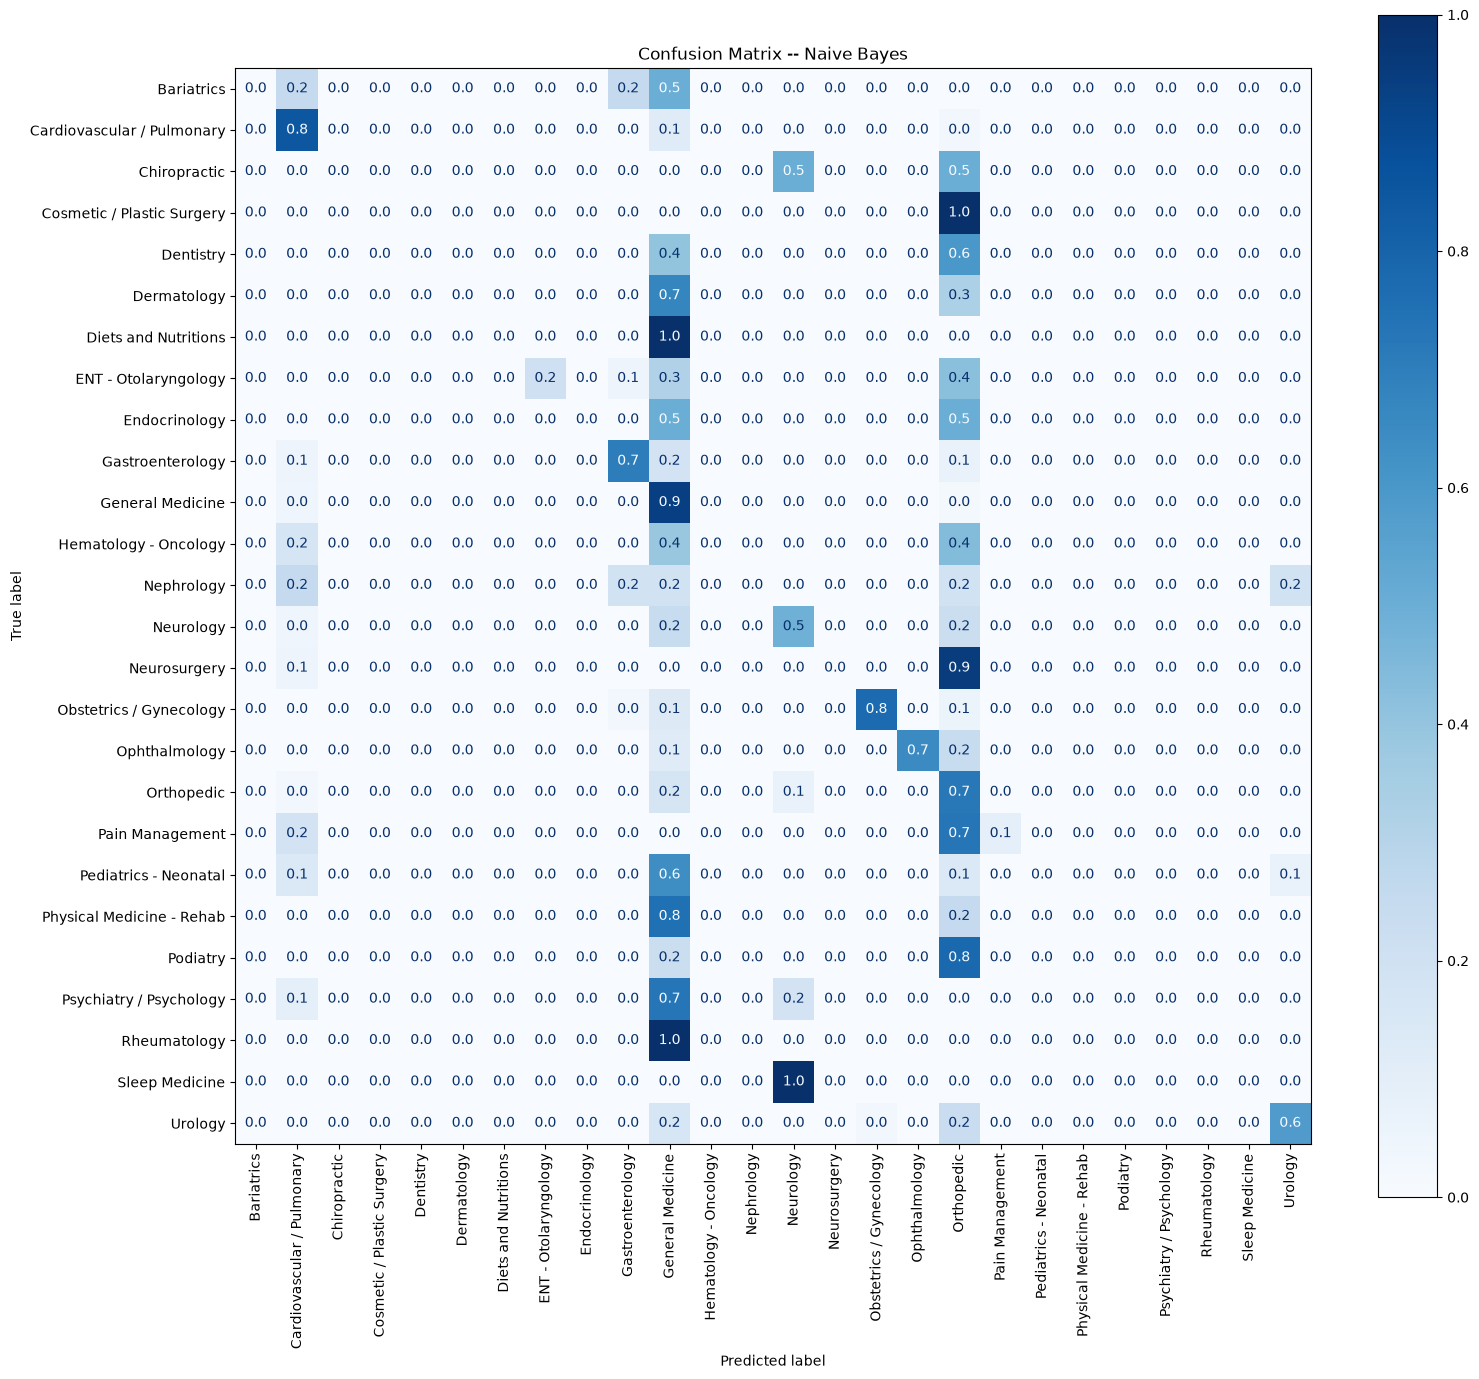

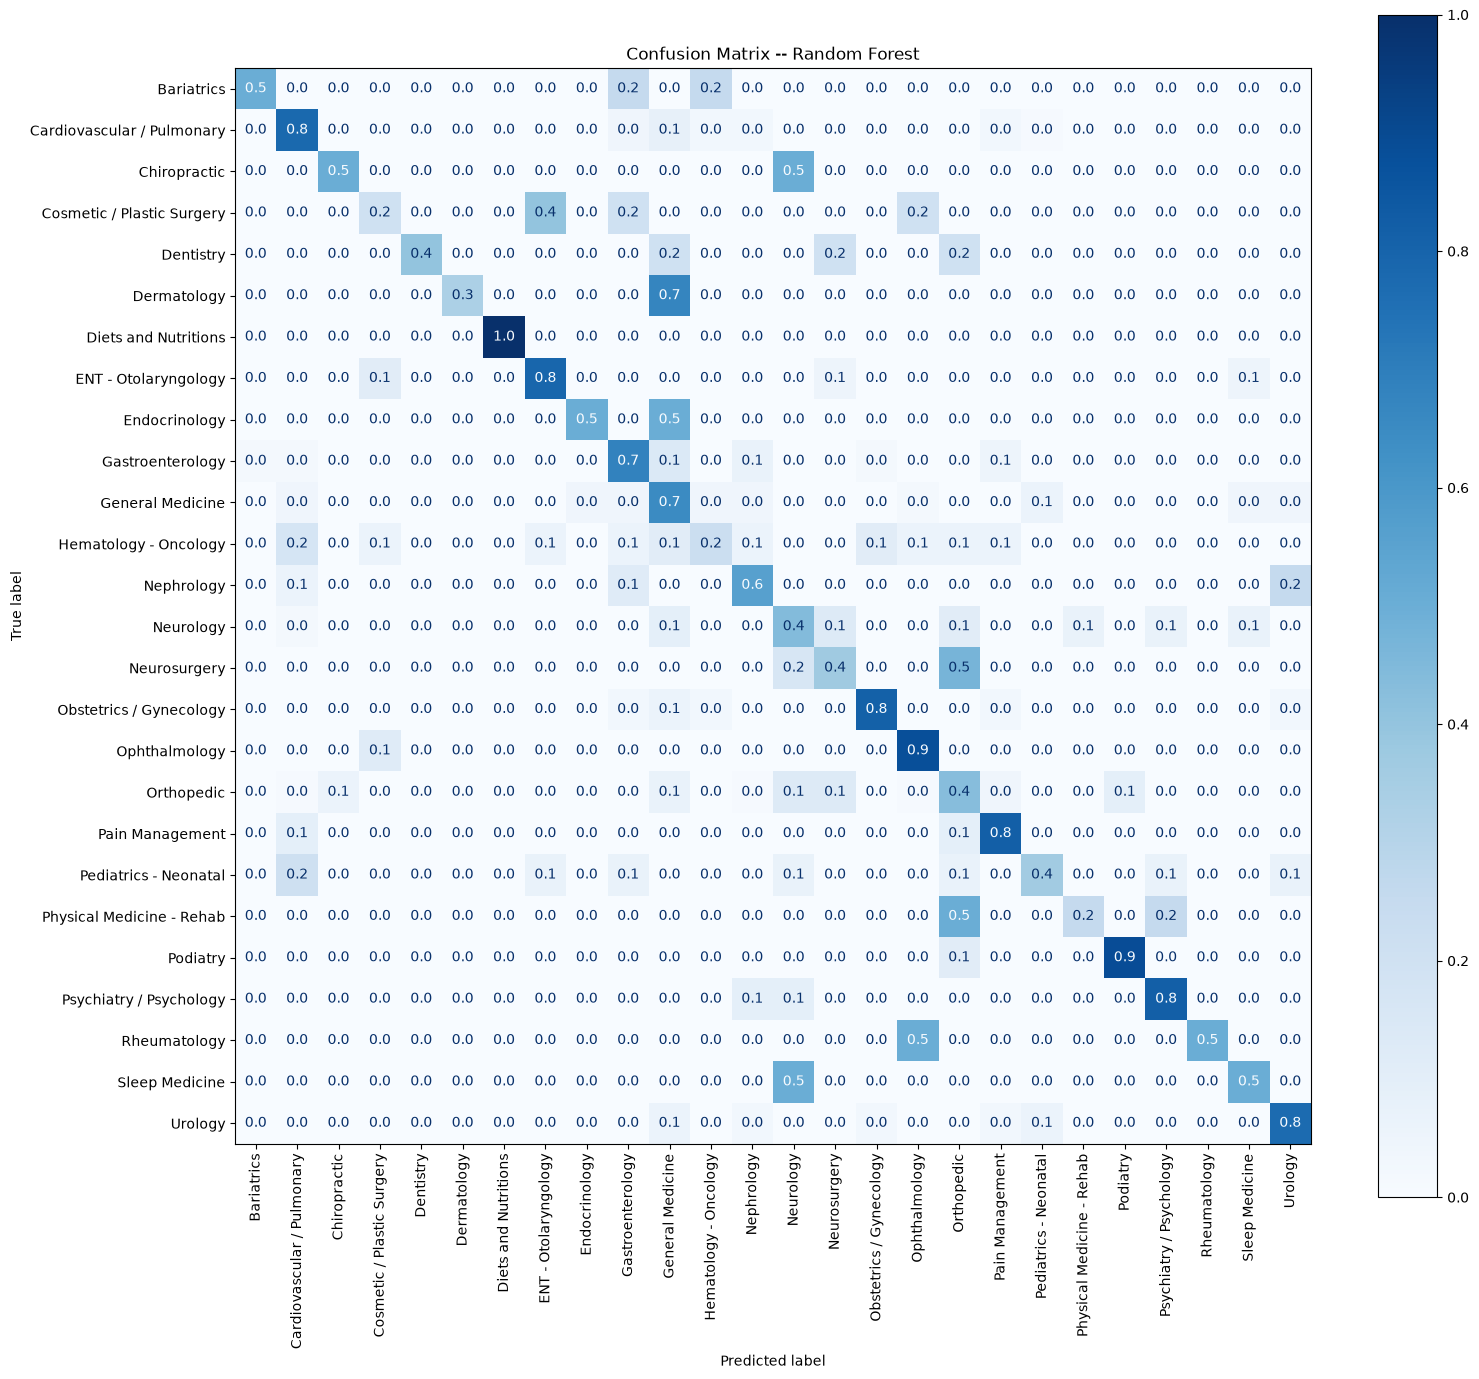

In [10]:
# sorted alphabetically for consistent axis ordering across all three plots
labels = sorted(y_test.unique())

models_list = [
    ('Logistic Regression', logreg_preds),
    ('Naive Bayes',         nb_preds),
    ('Random Forest',       rf_preds)
]

for name, preds in models_list:
    # normalize='true': each row divided by its row total
    # cells show proportions (0.0-1.0), not raw counts
    # removes the class-size effect -- large classes don't dominate visually
    cm = confusion_matrix(y_test, preds, labels=labels, normalize='true')

    fig, ax = plt.subplots(figsize=(16, 14))
    ConfusionMatrixDisplay(
        cm.round(2),              # round cell values to 2 decimal places
        display_labels=labels
    ).plot(
        ax=ax,
        xticks_rotation=90,       # rotate x-axis labels -- specialty names are long
        cmap='Blues',             # darker blue = higher proportion
        values_format='.1f'       # display 1 decimal per cell
    )
    plt.title(f'Confusion Matrix -- {name}')
    plt.tight_layout()
    plt.savefig(f'../outputs/figures/cm_{name.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

### Metric 3 — Error Analysis (Confident but Wrong)

We read cases where the model was *most certain* and still *wrong*. High-
confidence mistakes expose genuine weaknesses more than borderline guesses.

For each case, ask: is the "wrong" prediction actually a *reasonable* alternative
specialty? Many high-confidence errors on this dataset are cross-listed notes
where multiple labels are clinically valid — the model predicted correctly for
the note's content, but the test label happened to be the other valid one.

In [11]:
# get the model's probability distribution across all specialties per test note
# shape: (n_test_notes, n_specialties) -- one probability per specialty per note
probs = logreg.predict_proba(X_test_tfidf)

# confidence = the probability assigned to the model's top choice
confidence = probs.max(axis=1)               # max across columns per row

# the predicted class = whichever specialty got the highest probability
predicted = logreg.classes_[probs.argmax(axis=1)]

# assemble ground truth, prediction, confidence, and text into one frame
results = pd.DataFrame({
    'true':       y_test.values,
    'pred':       predicted,
    'confidence': confidence,
    'text':       X_test.values
})

# filter to wrong predictions, sorted by confidence descending
# "most confident first" = cases the model was most sure about and still got wrong
wrong = results[results['true'] != results['pred']].sort_values(
    'confidence', ascending=False
)

# read the top 5 high-confidence errors
for i, (_, row) in enumerate(wrong.head(5).iterrows(), 1):
    print(f"\n{'='*70}")
    print(f"CASE {i}  |  confidence: {row['confidence']:.2f}")
    print(f"TRUE: {row['true']}   PREDICTED: {row['pred']}")
    print(f"{'-'*70}")
    print(row['text'][:600])


CASE 1  |  confidence: 0.77
TRUE: Neurology   PREDICTED: Physical Medicine - Rehab
----------------------------------------------------------------------
history patient year old right handed female longstanding bilateral arm pain predominantly medial aspect arms hands well left hand numbness worse night repetitive work left hand denies weakness significant neck pain change bowel bladder symptoms change gait similar symptoms past lyrica pain somewhat successful examination reveals positive phalen test left remainder neurological examination normal nerve conduction studies left median motor distal latency prolonged normal evoked response amplitude conduction velocity left median sensory distal latency prolonged attenuated evoked response amplitu

CASE 2  |  confidence: 0.69
TRUE: Neurology   PREDICTED: Physical Medicine - Rehab
----------------------------------------------------------------------
history patient year old female past medical history diet controlled diabetes diffuse art

### Metric 4 — Interpretability: The "Full Circle" Moment

Logistic Regression's coefficients are the word weights it learned per specialty.
A large positive coefficient for "artery" under Cardiovascular means "when this
word is present, push hard toward Cardiovascular."

**The full circle:** Phase 2 chi-square identified words statistically bonded to
each specialty. Here, the trained model's top coefficients should surface those
same words — two completely independent methods (statistical analysis and ML
training) converging on the same vocabulary. That agreement is evidence the
model learned genuine medical knowledge, not artifacts.

In [12]:
feature_names = tfidf.get_feature_names_out()   # vocabulary words in column order
classes = logreg.classes_                        # specialty names in coefficient-row order

def top_words_for(specialty, n=10):
    # find which row of the coefficient matrix belongs to this specialty
    idx = list(classes).index(specialty)

    # logreg.coef_ shape: (n_specialties x n_features)
    # each row is one specialty's weight vector across all vocabulary words
    coefs = logreg.coef_[idx]

    # np.argsort returns indices sorted smallest-to-largest
    # [-n:] grabs the last n (the largest values)
    # [::-1] reverses to get largest-first
    top_idx = np.argsort(coefs)[-n:][::-1]

    return [(feature_names[i], round(coefs[i], 2)) for i in top_idx]

# compare these results to Phase 2 chi-square top words -- they should match
for spec in ['Cardiovascular / Pulmonary', 'Orthopedic', 'Neurology', 'Gastroenterology']:
    print(f"\n=== {spec} ===")
    print(top_words_for(spec))


=== Cardiovascular / Pulmonary ===
[('coronary', np.float64(1.34)), ('artery', np.float64(1.17)), ('chest', np.float64(1.12)), ('ventricular', np.float64(1.03)), ('atrial', np.float64(1.01)), ('heart', np.float64(0.96)), ('coronary artery', np.float64(0.93)), ('aortic', np.float64(0.91)), ('pulmonary', np.float64(0.87)), ('cardiac', np.float64(0.83))]

=== Orthopedic ===
[('fracture', np.float64(1.11)), ('tourniquet', np.float64(1.04)), ('joint', np.float64(0.95)), ('knee', np.float64(0.88)), ('tendon', np.float64(0.83)), ('extremity', np.float64(0.83)), ('ligament', np.float64(0.79)), ('bone', np.float64(0.79)), ('tear', np.float64(0.74)), ('carpal', np.float64(0.65))]

=== Neurology ===
[('brain', np.float64(1.19)), ('mri', np.float64(1.12)), ('gait', np.float64(0.93)), ('temporal', np.float64(0.87)), ('motor', np.float64(0.84)), ('exam', np.float64(0.81)), ('sensory', np.float64(0.8)), ('reflexes', np.float64(0.76)), ('eeg', np.float64(0.72)), ('unremarkable', np.float64(0.69))]

=

**Full circle confirmed** if these top coefficient words match your Phase 2
chi-square signatures. For example: Cardiovascular coefficients showing
"coronary, artery, atrial, aortic" should mirror Phase 2's chi-square top
words for that specialty. Two independent methods, same answer.

**Data-quality check:** if any artifact ("abc", "yearold") appears in the top
coefficients, the noise list needs updating. If only genuine medical terms appear,
the cleaning pipeline is validated end-to-end.

---
## Phase 3 Summary

| Model | Accuracy | Macro F1 | Key Characteristic |
|---|---|---|---|
| Logistic Regression | 0.701 | 0.657 | Interpretable, balanced |
| Naive Bayes | 0.527 | 0.227 | Fastest, no class weighting |
| Random Forest | 0.614 | 0.563 in | Non-linear, often weaker on sparse text |

**Key takeaways:**
- A large Accuracy-Macro F1 gap reveals a model favouring common specialties.
- Off-diagonal confusion hotspots reflect medically genuine vocabulary overlap.
- Coefficient-chi-square agreement closes the loop between Phase 2 EDA and Phase 3 modeling.
- Logistic Regression typically wins on sparse TF-IDF text -- simpler models often
  outperform complex ones in high-dimensional sparse feature spaces.